In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.ensemble import RandomForestRegressor

In [3]:
ml_dataset = pd.read_csv("cleaned_data.csv").copy()
ml_dataset

,start,end,duration,miles,category,purpose,duration_minutes,month,day,hour_of_day,day_of_week,day_of_week_name,start_date,end_date,is_peak_hr,is_weekend
0,Fort Pierce,Fort Pierce,0 days 00:06:00,5.1,Business,Meal/Entertain,6.0,1.0,1.0,21.0,4.0,Friday,2016-01-01,2016-01-01,0,0
1,Fort Pierce,Fort Pierce,0 days 00:12:00,5.0,Business,NaN,12.0,1.0,2.0,1.0,5.0,Saturday,2016-01-02,2016-01-02,0,1
2,Fort Pierce,Fort Pierce,0 days 00:13:00,4.8,Business,Errand/Supplies,13.0,1.0,2.0,20.0,5.0,Saturday,2016-01-02,2016-01-02,0,1
3,Fort Pierce,Fort Pierce,0 days 00:14:00,4.7,Business,Meeting,14.0,1.0,5.0,17.0,1.0,Tuesday,2016-01-05,2016-01-05,1,0
4,Fort Pierce,West Palm Beach,0 days 01:07:00,63.7,Business,Customer Visit,67.0,1.0,6.0,14.0,2.0,Wednesday,2016-01-06,2016-01-06,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1150,Karachi,Karachi,0 days 00:07:00,0.7,Business,Meeting,7.0,12.0,31.0,1.0,5.0,Saturday,2016-12-31,2016-12-31,0,1
1151,Karachi,Unknown Location,0 days 00:18:00,3.9,Business,Temporary Site,18.0,12.0,31.0,13.0,5.0,Saturday,2016-12-31,2016-12-31,0,1
1152,Unknown Location,Unknown Location,0 days 00:35:00,16.2,Business,Meeting,35.0,12.0,31.0,15.0,5.0,Saturday,2016-12-31,2016-12-31,0,1
1153,Katunayake,Gampaha,0 days 00:18:00,6.4,Business,Temporary Site,18.0,12.0,31.0,21.0,5.0,Saturday,2016-12-31,2016-12-31,0,1


In [4]:
demand_df = (
    ml_dataset.groupby([
        'start','hour_of_day','day_of_week' , 'category'
    ])
    .size()
    .reset_index(name='demand')
    )
demand_df

,start,hour_of_day,day_of_week,category,demand
0,Agnew,8.0,5.0,Business,1
1,Agnew,10.0,6.0,Business,1
2,Agnew,19.0,5.0,Business,1
3,Agnew,21.0,4.0,Business,1
4,Almond,12.0,6.0,Business,1
...,...,...,...,...,...
868,Whitebridge,20.0,0.0,Business,1
869,Whitebridge,20.0,1.0,Business,2
870,Whitebridge,20.0,4.0,Business,1
871,Whitebridge,21.0,1.0,Business,1


In [5]:
demand_df['demand'].describe()

count    873.000000
mean       1.323024
std        0.865302
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       12.000000
Name: demand, dtype: float64

In [6]:

demand_df['category'].value_counts()

category
Business    799
Personal     74
Name: count, dtype: int64

In [7]:
# x = features
# y = target
# demand_df['start','hour_of_day','day_of_week','category']

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

one hot encoding and label encoding


In [9]:
categories_encoded = pd.get_dummies(demand_df['category'] , dtype = int)
categories_encoded

,Business,Personal
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
868,1,0
869,1,0
870,1,0
871,1,0


In [10]:
label_encoder = LabelEncoder()
demand_df['encoded_start'] = label_encoder.fit_transform(demand_df['start'])

In [11]:
demand_df = pd.concat([ demand_df , categories_encoded ] , axis = 1)
demand_df

,start,hour_of_day,day_of_week,category,demand,encoded_start,Business,Personal
0,Agnew,8.0,5.0,Business,1,0,1,0
1,Agnew,10.0,6.0,Business,1,0,1,0
2,Agnew,19.0,5.0,Business,1,0,1,0
3,Agnew,21.0,4.0,Business,1,0,1,0
4,Almond,12.0,6.0,Business,1,1,1,0
...,...,...,...,...,...,...,...,...
868,Whitebridge,20.0,0.0,Business,1,174,1,0
869,Whitebridge,20.0,1.0,Business,2,174,1,0
870,Whitebridge,20.0,4.0,Business,1,174,1,0
871,Whitebridge,21.0,1.0,Business,1,174,1,0


In [12]:
x = demand_df[['encoded_start' , 'hour_of_day' , 'day_of_week' , 'Business' , 'Personal']]
y = demand_df['demand']
x , y

(     encoded_start  hour_of_day  day_of_week  Business  Personal
 0                0          8.0          5.0         1         0
 1                0         10.0          6.0         1         0
 2                0         19.0          5.0         1         0
 3                0         21.0          4.0         1         0
 4                1         12.0          6.0         1         0
 ..             ...          ...          ...       ...       ...
 868            174         20.0          0.0         1         0
 869            174         20.0          1.0         1         0
 870            174         20.0          4.0         1         0
 871            174         21.0          1.0         1         0
 872            175         18.0          4.0         1         0
 
 [873 rows x 5 columns],
 0      1
 1      1
 2      1
 3      1
 4      1
       ..
 868    1
 869    2
 870    1
 871    1
 872    1
 Name: demand, Length: 873, dtype: int64)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , root_mean_squared_error

In [14]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state= 42)

In [15]:
# x_train , y_train , x_test , y_test

In [16]:
model = RandomForestRegressor(random_state = 42)


In [17]:
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [18]:
model.fit(x_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
prediction = model.predict(x_test)


In [20]:
mae = mean_absolute_error(y_test , prediction)
rmse = root_mean_squared_error(y_test , prediction)

In [21]:
rmse , mae

(0.7722986099023763, 0.42508571428571423)

In [22]:
results = pd.DataFrame({
    'Actual' :y_test.values , 
    'Predicted' : prediction
})
results.head(10)

,Actual,Predicted
0,1,1.01
1,3,1.08
2,1,1.06
3,1,1.70
4,1,1.42
5,1,1.21
6,1,1.00
7,2,1.52
8,1,1.00
9,1,1.03


In [23]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Actual vs Predicted')

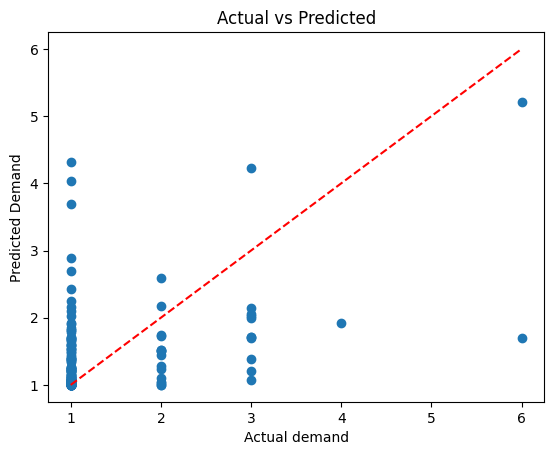

In [24]:
plt.figure()
plt.scatter(y_test , prediction)
plt.plot([y_test.min() , y_test.max()],[y_test.min() , y_test.max()],linestyle = '--' , color = 'red')
plt.xlabel("Actual demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted")


In [25]:
demand_df['start'].unique()

<StringArray>
[                    'Agnew',                    'Almond',
                      'Apex',                     'Arabi',
                 'Arlington', 'Arlington Park at Amberly',
                 'Asheville',                    'Austin',
                'Banner Elk',                  'Bellevue',
 ...
             'Waverly Place',               'Wayne Ridge',
             'West Berkeley',                  'West End',
           'West Palm Beach',           'West University',
                    'Weston',            'Westpark Place',
               'Whitebridge',             'Winston Salem']
Length: 176, dtype: str

In [26]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, prediction)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.42508571428571423
RMSE: 0.7722986099023763
R²: -0.0023119238366990924


In [27]:
print(model.feature_importances_)

[0.30409607 0.4637866  0.22257721 0.00535861 0.00418152]


In [28]:
importance = pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(importance)

hour_of_day      0.463787
encoded_start    0.304096
day_of_week      0.222577
Business         0.005359
Personal         0.004182
dtype: float64


In [29]:
demand_df['start'].value_counts().describe()

count    176.000000
mean       4.960227
std       11.634609
min        1.000000
25%        1.000000
50%        1.000000
75%        4.000000
max       93.000000
Name: count, dtype: float64

In [30]:
demand_df['demand'].value_counts().sort_index

<bound method Series.sort_index of demand
1     700
2     112
3      40
4      10
5       5
6       4
10      1
12      1
Name: count, dtype: int64>

In [31]:
demand_df['demand'].describe()

count    873.000000
mean       1.323024
std        0.865302
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       12.000000
Name: demand, dtype: float64

In [32]:
# demand_df2 = (
#     demand_df.groupby(['start' , 'hour_of_day']).size().reset_index(name='demand')
# )
# # demand_f2.value_counts().sort_index()
# print(demand_f2.describe())


In [33]:
# X = demand_df2[['start', 'hour_of_day']]

# Y = demand_df2['demand']



In [34]:
# X_train, X_test, Y_train, Y_test = train_test_split(
#     X,
#     Y,
#     test_size=0.2,
#     random_state=42
# )

# print("Training rows:", len(X_train))
# print("Testing rows:", len(X_test))

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [36]:
categorical_features = ['start']
preprocessor = ColumnTransformer(
    transformers=[
        ('location', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [37]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=100
    ))
])

In [38]:
# model_pipeline.fit(X_train, Y_train)

# print("Model trained successfully! 🚕")

In [39]:
# ============================================
# RIDE PULSE - DEMAND PREDICTION MODEL
# ============================================

# 1. IMPORT LIBRARIES
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

# ============================================
# 2. CREATE DEMAND DATASET
# ============================================

# One row = one starting location + one hour
demand_df2 = (
    demand_df.groupby(['start', 'hour_of_day'])
      .size()
      .reset_index(name='demand')
)

print("Demand dataset created!")
print("\nFirst 10 rows:")
print(demand_df2.head(10))

print("\nShape:")
print(demand_df2.shape)

print("\nDemand distribution:")
print(demand_df2['demand'].value_counts().sort_index())

print("\nDemand statistics:")
print(demand_df2['demand'].describe())


# ============================================
# 3. CREATE FEATURES (X) AND TARGET (y)
# ============================================

X = demand_df2[['start', 'hour_of_day']].copy()

y = demand_df2['demand'].copy()

print("\n==============================")
print("FEATURES (X)")
print("==============================")
print(X.head())

print("\nX columns:")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.head())


# ============================================
# 4. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n==============================")
print("TRAIN / TEST SPLIT")
print("==============================")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


# ============================================
# 5. ENCODE START LOCATION
# ============================================

# 'start' is categorical/text data.
# hour_of_day is already numerical.

preprocessor = ColumnTransformer(
    transformers=[
        (
            'location',
            OneHotEncoder(handle_unknown='ignore'),
            ['start']
        )
    ],
    remainder='passthrough'
)


# ============================================
# 6. CREATE RANDOM FOREST PIPELINE
# ============================================

model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)


# ============================================
# 7. TRAIN MODEL
# ============================================

model_pipeline.fit(X_train, y_train)

print("\n==============================")
print("MODEL TRAINING")
print("==============================")
print("✅ Model trained successfully!")


# ============================================
# 8. MAKE PREDICTIONS
# ============================================

predictions2 = model_pipeline.predict(X_test)


# ============================================
# 9. EVALUATE MODEL
# ============================================

mae2 = mean_absolute_error(y_test, predictions2)

rmse2 = root_mean_squared_error(
    y_test,
    predictions2
)

r2_2 = r2_score(
    y_test,
    predictions2
)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"MAE  : {mae2:.3f}")
print(f"RMSE : {rmse2:.3f}")
print(f"R²   : {r2_2:.3f}")


# ============================================
# 10. ACTUAL VS PREDICTED
# ============================================

results = pd.DataFrame({
    'Actual Demand': y_test.values,
    'Predicted Demand': predictions2
})

print("\n==============================")
print("ACTUAL VS PREDICTED")
print("==============================")

print(results.head(15))

Demand dataset created!

First 10 rows:
    start  hour_of_day  demand
0   Agnew          8.0       1
1   Agnew         10.0       1
2   Agnew         19.0       1
3   Agnew         21.0       1
4  Almond         12.0       1
5    Apex         12.0       1
6    Apex         13.0       1
7    Apex         14.0       1
8    Apex         15.0       2
9    Apex         17.0       1

Shape:
(527, 3)

Demand distribution:
demand
1    383
2     63
3     24
4     24
5     11
6     15
7      5
8      2
Name: count, dtype: int64

Demand statistics:
count    527.000000
mean       1.656546
std        1.362755
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        8.000000
Name: demand, dtype: float64

FEATURES (X)
    start  hour_of_day
0   Agnew          8.0
1   Agnew         10.0
2   Agnew         19.0
3   Agnew         21.0
4  Almond         12.0

X columns:
['start', 'hour_of_day']

Target (y):
0    1
1    1
2    1
3    1
4    1
Name: demand, dtype: int64

T

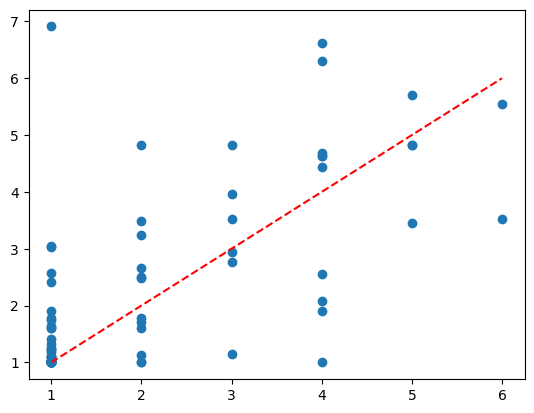

In [40]:

plt.figure()
plt.scatter(y_test.values ,  predictions2 )
plt.plot([y_test.values.min() , y_test.values.max()],[y_test.values.min() , y_test.values.max()],linestyle = '--' , color = 'red')

In [41]:
demand_df3 = (
    demand_df.groupby(['start', 'hour_of_day', 'day_of_week'])
      .size()
      .reset_index(name='demand')
)

print(demand_df3.head())
print("Shape:", demand_df3.shape)

print("\nDemand statistics:")
print(demand_df3['demand'].describe()) 
X = demand_df3[['start', 'hour_of_day', 'day_of_week']].copy()
y = demand_df3['demand'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'location',
            OneHotEncoder(handle_unknown='ignore'),
            ['start']
        )
    ],
    remainder='passthrough'
)

model_pipeline3 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

model_pipeline3.fit(X_train, y_train)

predictions3 = model_pipeline3.predict(X_test)
mae3 = mean_absolute_error(y_test, predictions3)
rmse3 = root_mean_squared_error(y_test, predictions3)
r2_3 = r2_score(y_test, predictions3)

print(f"MAE  : {mae3:.3f}")
print(f"RMSE : {rmse3:.3f}")
print(f"R²   : {r2_3:.3f}")

    start  hour_of_day  day_of_week  demand
0   Agnew          8.0          5.0       1
1   Agnew         10.0          6.0       1
2   Agnew         19.0          5.0       1
3   Agnew         21.0          4.0       1
4  Almond         12.0          6.0       1
Shape: (862, 4)

Demand statistics:
count    862.000000
mean       1.012761
std        0.112307
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: demand, dtype: float64
MAE  : 0.039
RMSE : 0.148
R²   : -2.790


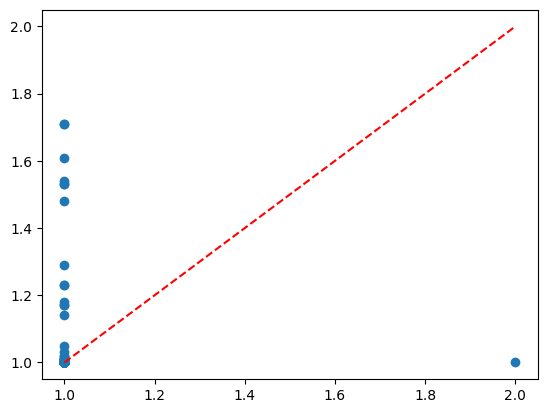

In [42]:

plt.figure()
plt.scatter(y_test ,  predictions3 )
plt.plot([y_test.min() , y_test.max()],[y_test.min() , y_test.max()],linestyle = '--' , color = 'red')

Above model is not effective therefore moving with demand_df2

In [50]:
# Find demand thresholds from our training dataset
low_threshold = demand_df2['demand'].quantile(0.25)
high_threshold = demand_df2['demand'].quantile(0.75)

print("Low threshold:", low_threshold)
print("High threshold:", high_threshold)

Low threshold: 1.0
High threshold: 2.0


In [51]:
def get_demand_level(demand):
    if demand <= low_threshold:
        return "LOW"
    elif demand <= high_threshold:
        return "MEDIUM"
    else:
        return "HIGH"

In [52]:
sample_ride = pd.DataFrame({
    'start': ['Cary'],
    'hour_of_day': [18]
})

predicted_demand = model_pipeline.predict(sample_ride)[0]

demand_level = get_demand_level(predicted_demand)

print("🚕 Start Location:", sample_ride['start'][0])
print("🕐 Hour:", sample_ride['hour_of_day'][0])
print(f"📊 Predicted Demand: {predicted_demand:.2f}")
print("🔥 Demand Level:", demand_level)

🚕 Start Location: Cary
🕐 Hour: 18
📊 Predicted Demand: 6.65
🔥 Demand Level: HIGH


In [54]:
import joblib

model_package = {
    'model': model_pipeline,
    'low_threshold': low_threshold,
    'high_threshold': high_threshold
}

joblib.dump(model_package, 'ride_demand_model.pkl')

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [47]:
loaded_package = joblib.load('ride_demand_model.pkl')

loaded_model = loaded_package['model']
low_threshold = loaded_package['low_threshold']
high_threshold = loaded_package['high_threshold']

In [53]:
sample_ride = pd.DataFrame({
    'start': ['Cary'],
    'hour_of_day': [18]
})

prediction = loaded_model.predict(sample_ride)[0]

print("Predicted demand:", round(prediction, 2))

Predicted demand: 6.65
